In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("mental_health_synthetic_dataset_10k.csv")
print("Shape:", df.shape)
df.head()

Shape: (10000, 66)


,profile,language,total_word_count,unique_word_count,ttr,positive_emotion_ratio,negative_emotion_ratio,fear_word_frequency,sadness_word_frequency,anger_word_frequency,...,emb_23,emb_24,emb_25,emb_26,emb_27,emb_28,emb_29,emb_30,emb_31,target
0,Anxiety,english,375,203,0.543053,0.030357,0.081635,0.088873,0.005106,0.040381,...,0.451957,-2.688339,0.256804,-0.188136,-0.013305,0.653549,1.480412,-0.253776,-0.760361,Anxiety
1,Suicidal_Tendency,english,198,97,0.488689,0.004810,0.128472,0.045492,0.174600,0.008384,...,-0.576675,0.993651,1.012413,-1.751549,0.538784,1.544498,-0.944134,-0.155736,0.687352,Suicidal_Tendency
2,Bipolar_Mania,english,461,330,0.716359,0.018945,0.028211,0.022398,0.019481,0.053633,...,1.580858,0.339946,0.416768,0.831984,1.176717,0.241540,-1.949057,-0.363932,0.397892,Bipolar_Mania
3,Stress,hindi,352,144,0.408843,0.023118,0.070132,0.015014,0.021300,0.105607,...,0.284078,-0.792665,-0.167156,-1.263046,-1.268401,0.269440,-1.268528,-1.826403,-1.325447,Stress
4,Depression,hindi,297,156,0.527356,0.012338,0.078112,0.016293,0.036441,0.049589,...,0.820437,1.125139,1.653052,1.542981,-0.638913,0.468540,0.169073,1.270841,1.747420,Depression


In [ ]:
## 1. Basic Info

In [2]:
print("=== dtypes & nulls ===")
info = pd.DataFrame({
    "dtype":    df.dtypes,
    "nulls":    df.isnull().sum(),
    "null_%":   (df.isnull().mean() * 100).round(2),
})
print(info[info["nulls"] > 0].to_string() or "No missing values found ✓")
print("\n=== Numeric summary ===")
df.describe().T.round(3)

=== dtypes & nulls ===
Empty DataFrame
Columns: [dtype, nulls, null_%]
Index: []

=== Numeric summary ===


,count,mean,std,min,25%,50%,75%,max
total_word_count,10000.0,339.697,154.096,50.000,237.000,322.000,414.000,1281.000
unique_word_count,10000.0,170.050,88.841,15.000,108.000,155.000,212.000,727.000
ttr,10000.0,0.501,0.117,0.200,0.420,0.501,0.580,0.887
positive_emotion_ratio,10000.0,0.033,0.019,0.000,0.018,0.030,0.046,0.113
negative_emotion_ratio,10000.0,0.070,0.046,0.000,0.039,0.062,0.090,0.366
...,...,...,...,...,...,...,...,...
emb_27,10000.0,-0.009,1.011,-3.672,-0.699,-0.007,0.688,3.443
emb_28,10000.0,-0.012,0.990,-3.656,-0.680,-0.018,0.666,3.609
emb_29,10000.0,-0.007,1.002,-4.016,-0.685,-0.014,0.658,3.775
emb_30,10000.0,0.004,0.994,-3.605,-0.664,0.000,0.678,3.415


In [ ]:
## 2. Target Class Distribution

target
Depression           2547
Anxiety              2035
Stress               2021
Bipolar_Mania        1435
Phobia               1001
Suicidal_Tendency     961


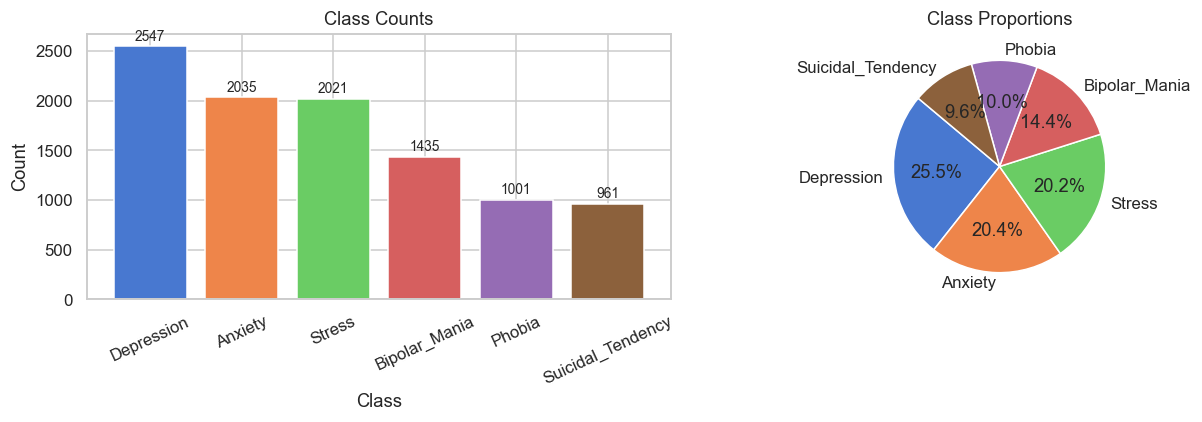

In [3]:
counts = df["target"].value_counts()
print(counts.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = sns.color_palette("muted", len(counts))
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title("Class Counts")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=25)
for bar, v in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 30, str(v),
                 ha="center", va="bottom", fontsize=9)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=colors, startangle=140)
axes[1].set_title("Class Proportions")

plt.tight_layout()
plt.show()

In [ ]:
## 3. Key Feature Distributions by Class

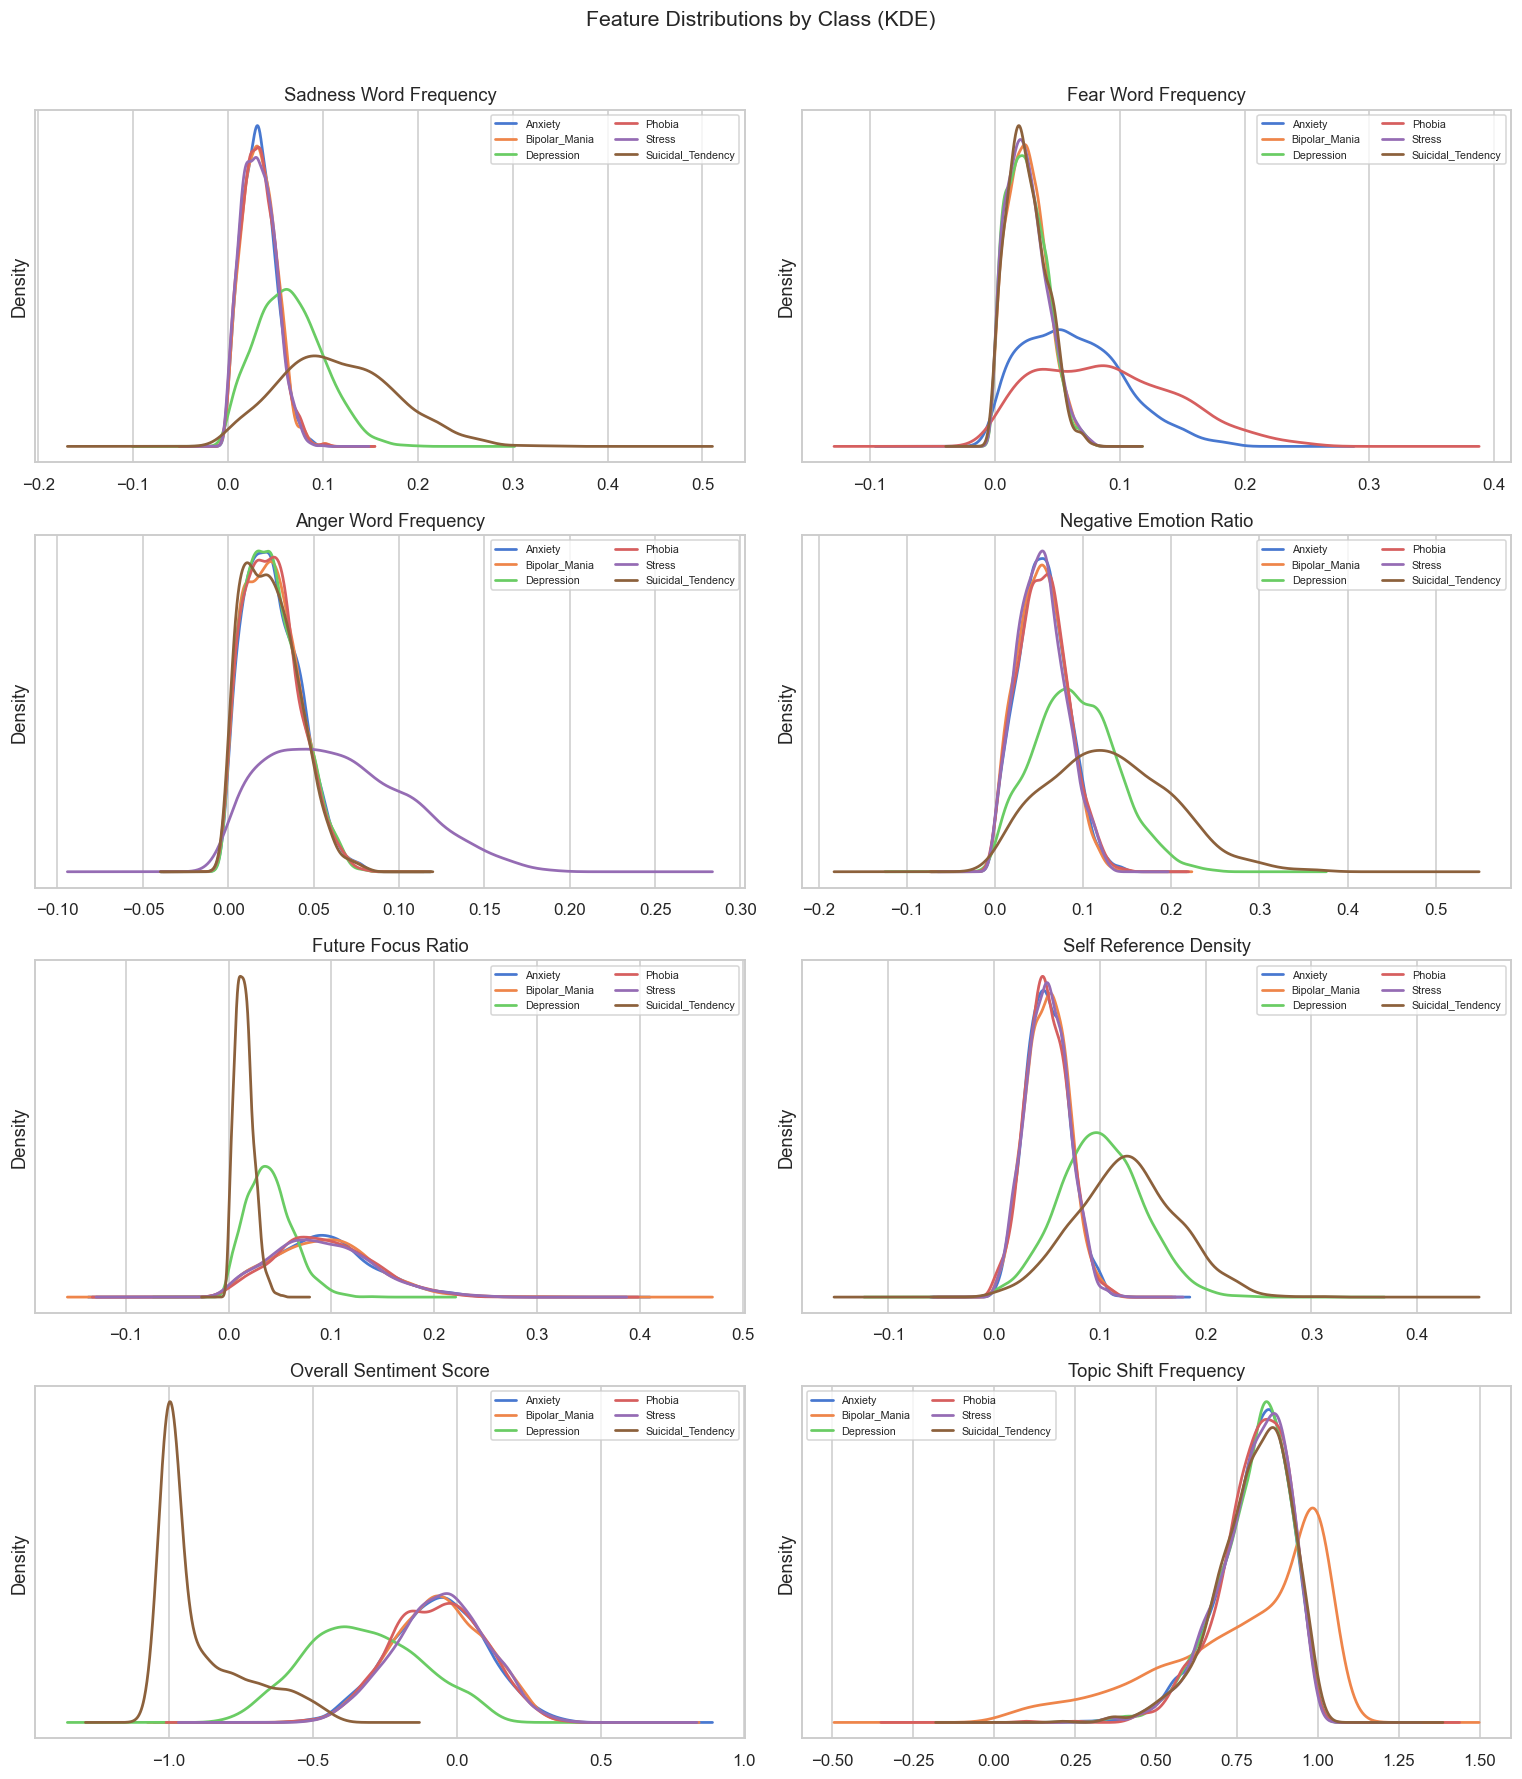

In [4]:
key_features = [
    "sadness_word_frequency",
    "fear_word_frequency",
    "anger_word_frequency",
    "negative_emotion_ratio",
    "future_focus_ratio",
    "self_reference_density",
    "overall_sentiment_score",
    "topic_shift_frequency",
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

classes    = df["target"].unique()
palette    = sns.color_palette("muted", len(classes))
class_colors = dict(zip(sorted(classes), palette))

for ax, feat in zip(axes, key_features):
    for cls in sorted(classes):
        subset = df.loc[df["target"] == cls, feat]
        subset.plot.kde(ax=ax, label=cls, color=class_colors[cls], linewidth=1.8)
    ax.set_title(feat.replace("_", " ").title())
    ax.set_xlabel("")
    ax.legend(fontsize=7, ncol=2)
    ax.set_yticks([])

plt.suptitle("Feature Distributions by Class (KDE)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
## 4. Correlation Heatmap (Linguistic Features)

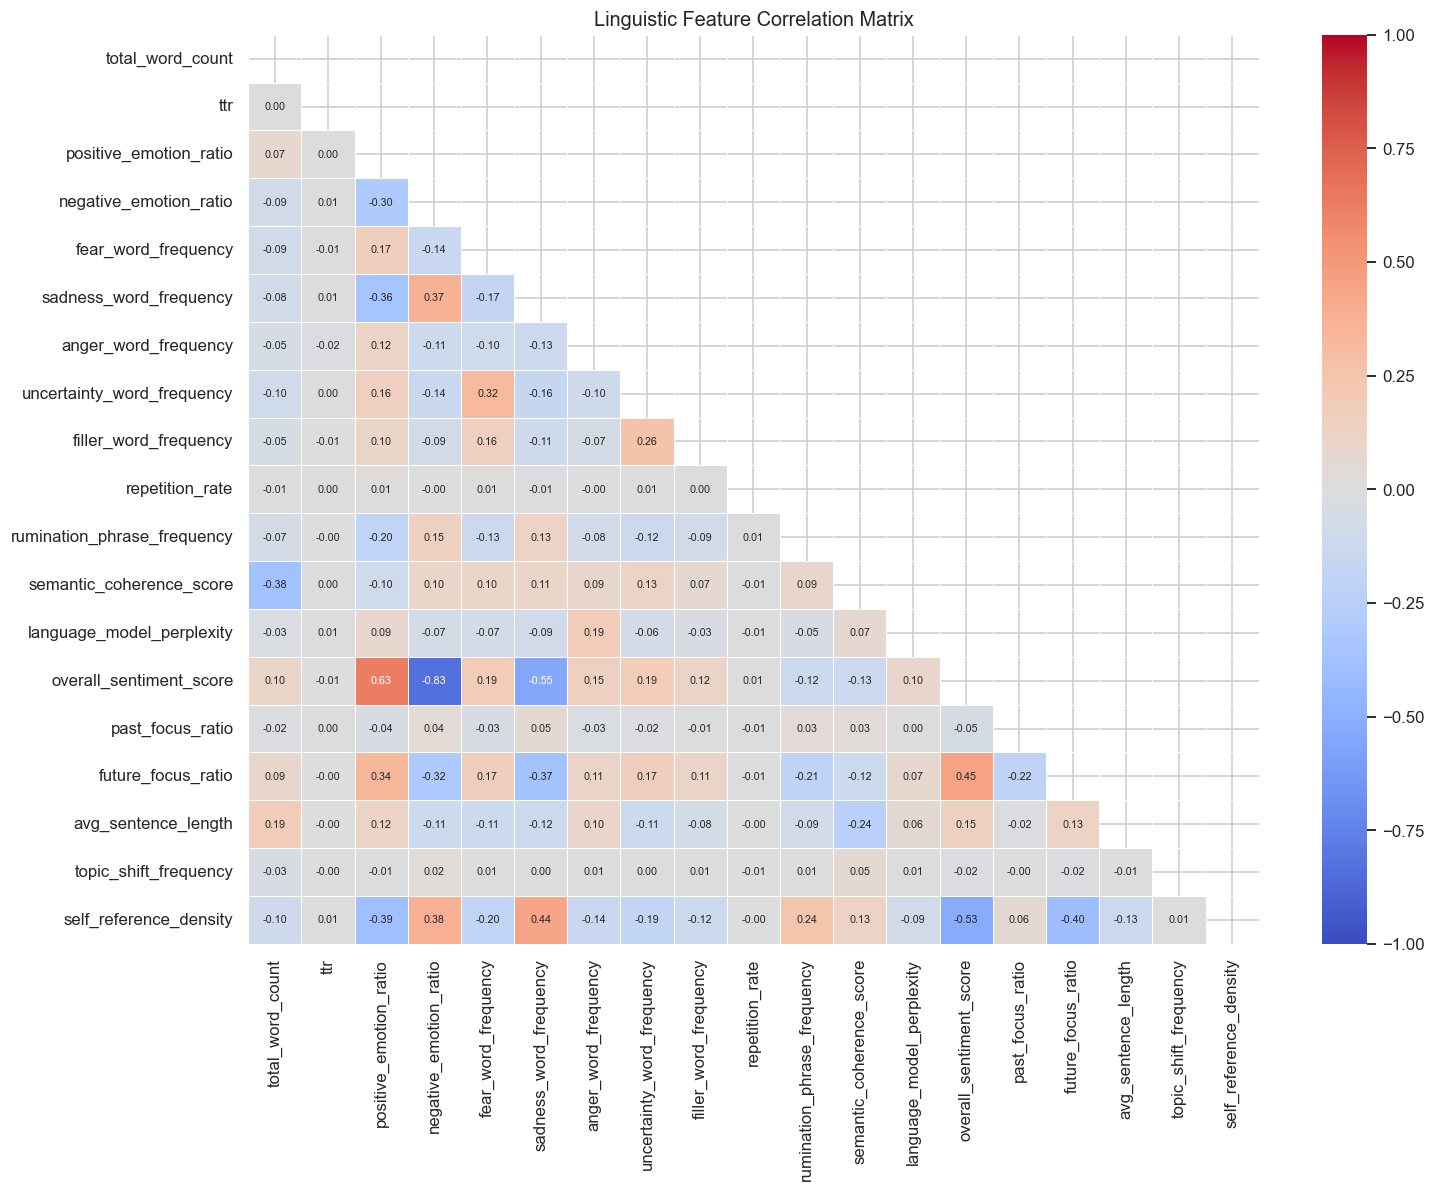

In [6]:
ling_cols = [
    "total_word_count", "ttr", "positive_emotion_ratio", "negative_emotion_ratio",
    "fear_word_frequency", "sadness_word_frequency", "anger_word_frequency",
    "uncertainty_word_frequency", "filler_word_frequency", "repetition_rate",
    "rumination_phrase_frequency", "semantic_coherence_score",
    "language_model_perplexity", "overall_sentiment_score",
    "past_focus_ratio", "future_focus_ratio", "avg_sentence_length",
    "topic_shift_frequency", "self_reference_density",
]

corr = df[ling_cols].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.4, annot_kws={"size": 7}, vmin=-1, vmax=1)
plt.title("Linguistic Feature Correlation Matrix", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Median Feature Values per Class (Heatmap)

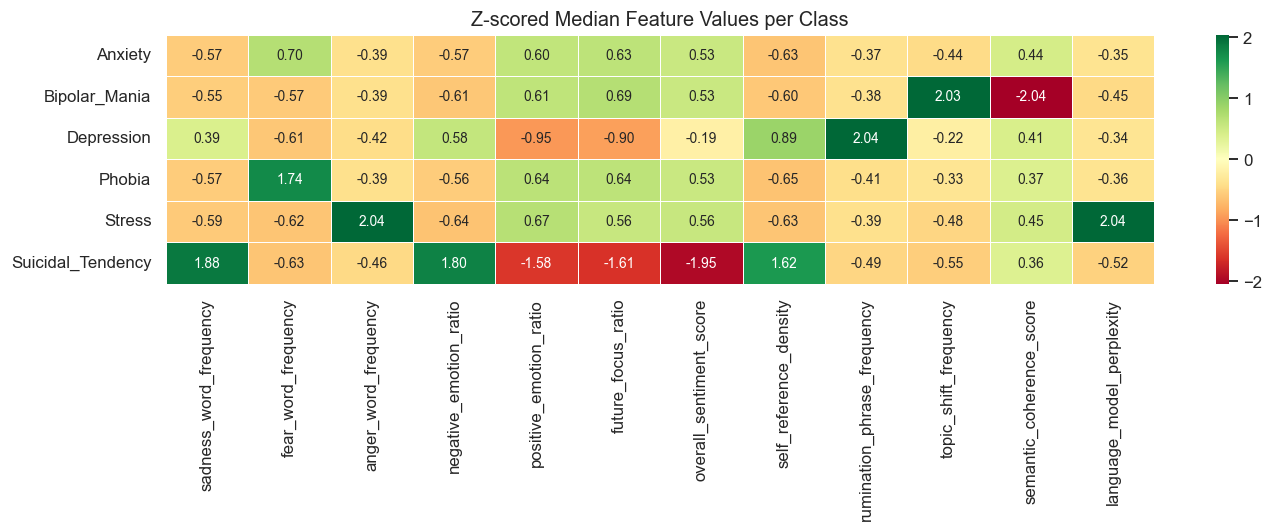

In [7]:
signal_cols = [
    "sadness_word_frequency", "fear_word_frequency", "anger_word_frequency",
    "negative_emotion_ratio", "positive_emotion_ratio", "future_focus_ratio",
    "overall_sentiment_score", "self_reference_density",
    "rumination_phrase_frequency", "topic_shift_frequency",
    "semantic_coherence_score", "language_model_perplexity",
]

medians = df.groupby("target")[signal_cols].median()
# Z-score each column so scale differences don't dominate
medians_z = (medians - medians.mean()) / medians.std()

plt.figure(figsize=(13, 5))
sns.heatmap(medians_z, annot=True, fmt=".2f", cmap="RdYlGn",
            linewidths=0.5, annot_kws={"size": 9}, center=0)
plt.title("Z-scored Median Feature Values per Class", fontsize=13)
plt.ylabel("")
plt.tight_layout()
plt.show()

## 6. Language Distribution

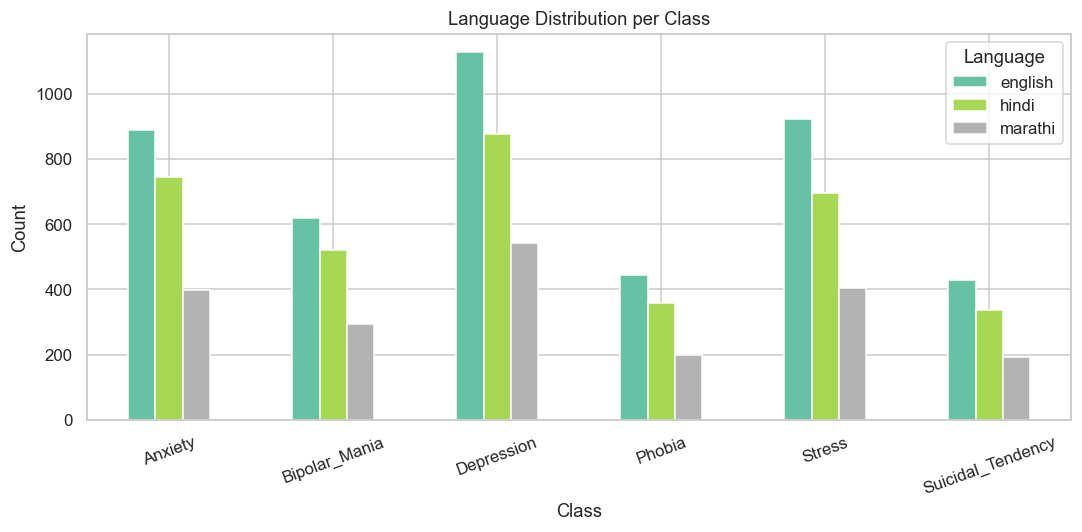

In [8]:
lang_class = df.groupby(["target", "language"]).size().unstack(fill_value=0)

lang_class.plot(kind="bar", figsize=(10, 5), colormap="Set2", edgecolor="white")
plt.title("Language Distribution per Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.legend(title="Language")
plt.tight_layout()
plt.show()